# RSM338 Assignment 6 Part A: Classification
## April 8, 2026
### Ethan Wang, Kevin Yang

## 1. Data Preparation (Reused from Assignment 5)

In [1]:
# Load in the data
import pandas as pd

df = pd.read_excel('lending_clubFull_Data_Set.xlsx')
df

,Unnamed: 0,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,0,263591,545710,20000.0,60 months,17.93,342.94,E,E5,Wylie ISD,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,1,1613916,69664096,30000.0,36 months,11.99,996.29,C,C1,Sergeant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
2,2,818934,8965180,21500.0,36 months,11.99,714.01,B,B3,Designer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
3,3,1606612,70572960,10000.0,36 months,13.67,340.18,C,C3,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
4,4,1639932,68589517,5000.0,36 months,8.49,157.82,B,B1,Sr. Manufacturing Engineer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,901888,4974773,10500.0,36 months,10.16,339.60,B,B1,Schneider Electric,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24996,24996,945413,1279809,12000.0,36 months,14.33,412.06,C,C1,Clark County School District,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24997,24997,366944,63496281,25000.0,36 months,12.69,838.63,C,C2,sales consultant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24998,24998,1043529,98124387,12200.0,60 months,13.49,280.66,C,C2,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN


Now that we loaded the data, we must  choose useful features for our analysis. As stated, many of the columns are redundant, so we should try to make our dataset more managable before our analysis.

### 1.1 Defining the Target Variable
We need a binary outcome for the loans - default or not - but we are given several outcomes. Let's first see all the unique loan outcomes.

In [2]:
# Display all unique values in the 'loan_status' column
unique_loan_status = df['loan_status'].unique()
unique_loan_status

array(['Charged Off', 'Current', 'Fully Paid', 'Late (31-120 days)',
       'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off', 'Default',
       nan], dtype=object)

In [3]:
# Define which categories count as Default
default_categories = ['Default','Charged Off','Late (31-120 days)','Late (16-30 days)','Does not meet the credit policy. Status:Charged Off']
repaid_categories = ['Fully Paid','Does not meet the credit policy. Status:Fully Paid']

df = df[df['loan_status'].isin(default_categories + repaid_categories)]
# Create target
df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in default_categories else 0
)

/var/folders/b8/7s__rx195mv3c_l3b3gd3vkr0000gn/T/ipykernel_5235/3997849371.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['default'] = df['loan_status'].apply(


We define default (1) as loans with statuses of 'Charged Off', 'Default', 'Late (16-30 days)', 'Late (31-120 days)', or 'Does not meet the credit policy Status:Charged Off'. From a lender's perspective, 'Charged Off' represents a material loss where the debt is unlikely to be collected. We include late loans as a functional default because statistically, loans that fall this far behind have a lower probability of returning to 'Current' status, essentially representing a total loss of expected cash flow. 
  
The repaid categories include Fully Paid',and 'Does not meet the credit policy. Status:Fully Paid'. For categories outside the default categories and repaid categories, we will drop them from our analysis, since we have no way of knowing whether they would be a default or not.



### 1.2 Selecting Features
While selecting the features, we made sure to find features that are backwards looking and can tell us about the relevant credit characteristics of the borrower.

'fico_range_low' and 'grade' provide a verified snapshot of the borrower's credit history at the exact moment of their application. These features are "crystallized" from the time of origination, making them highly reliable for predicting risk without including information from the future.

'annual_inc' (annual income) and 'dti' (monthly debt-to-income ratio) tell us about the earning power of the borrower. Even if a borrower faces unfortunate circumstances, a strong basis for their ability to repay suggests the debt can be recovered over time.

'home_ownership' (ownership status) and 'emp_length' (tenure in years) tell us if the borrower has a stable life. Borrowers with stability in their housing and employment will have much more predictable repayments compared to those who are frequently moving or job-hopping.

'loan_amnt' (the amount applied for) tells us about the overall burden of the loan on the borrower. 'term' tells us how long the loan will be. 'int_rate' tells us the interest rate on the loan. It helps determine if the repayments are feasible relative to the borrower's perceived debt capacity and appetite for risk. 'purpose' and 'open_acc' also give a snapshot on the borrower's behaviour and debt capacity.

'pub_rec_bankruptcies' and 'pub_rec' provide insight on the public historical records of the borrower, such as past bankruptcies or past failures to pay.


In [4]:
# SWAP: Removed 'num_accts_ever_120_pd' and 'pct_tl_nvr_dlq'
# ADDED: 'fico_range_low'
features_to_use = [
    'annual_inc', 'dti', 'loan_amnt', 'emp_length', 
    'home_ownership', 'fico_range_low', 'pub_rec_bankruptcies',
    'pub_rec','term','int_rate','grade', 'purpose', 'open_acc'
]

### 1.3 Handling Missing Values and Data Types 

In [5]:
df[features_to_use].isna().sum()

annual_inc                0
dti                       1
loan_amnt                 0
emp_length              702
home_ownership            0
fico_range_low            0
pub_rec_bankruptcies     18
pub_rec                   1
term                      0
int_rate                  0
grade                     0
purpose                   0
open_acc                  1
dtype: int64

Theoretically, no applicant should have missing values in any of the columns. We have over 25,000 observations, and the only significant feature with a lot of missing values is *emp_length*, with 1,502 missing values. Therefore, we choose to impute missing values for emp_length using the median value. This is in case defaults tend to have more missing information, such as employment length.

 For the rest of the features, because the amount missing is minimal, we choose to drop missing values.
  
For emp_length, we decided to map the data type to integers. We chose to assign '< 1 year' to 0, and '10+ years' to 10. We believe that this is the most logical ranking for employment length, as it keeps the integer values in the original dataset, while providing intuitive values for the non-integer values.

In [6]:
emp_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df['emp_length'] = df['emp_length'].map(emp_map)

# Impute missing values
med = df['emp_length'].median()
df['emp_length'] = df['emp_length'].fillna(med)
# Check the result - it should now be 0.0 to 10.0
print(df['emp_length'].value_counts())

emp_length
10.0    4155
6.0     1375
2.0     1203
3.0     1028
0.0      946
4.0      802
1.0      801
5.0      760
8.0      597
7.0      585
9.0      510
Name: count, dtype: int64


/var/folders/b8/7s__rx195mv3c_l3b3gd3vkr0000gn/T/ipykernel_5235/1706004684.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emp_length'] = df['emp_length'].map(emp_map)
/var/folders/b8/7s__rx195mv3c_l3b3gd3vkr0000gn/T/ipykernel_5235/1706004684.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emp_length'] = df['emp_length'].fillna(med)


In [7]:
df[features_to_use].isna().sum()

annual_inc               0
dti                      1
loan_amnt                0
emp_length               0
home_ownership           0
fico_range_low           0
pub_rec_bankruptcies    18
pub_rec                  1
term                     0
int_rate                 0
grade                    0
purpose                  0
open_acc                 1
dtype: int64

In [8]:
# 1. Handle missing values (Example: dropping rows with any NAs in selected features)
df_cleaned = df[features_to_use + ['default']].dropna()
df_cleaned.isna().sum()

annual_inc              0
dti                     0
loan_amnt               0
emp_length              0
home_ownership          0
fico_range_low          0
pub_rec_bankruptcies    0
pub_rec                 0
term                    0
int_rate                0
grade                   0
purpose                 0
open_acc                0
default                 0
dtype: int64

We can confirm that all missing values have been taken care of.

In [9]:
# Display all unique values in the 'home_ownership' column
unique_home_status = df['home_ownership'].unique()
unique_home_status

array(['MORTGAGE', 'RENT', 'OWN', 'OTHER', 'NONE', 'ANY'], dtype=object)

In [10]:
unique_grade = df['grade'].unique()
unique_grade

array(['E', 'B', 'C', 'F', 'D', 'A', 'G'], dtype=object)

In [11]:
# Selecting categorical columns
categorical_cols = ['home_ownership', 'grade','purpose']

# Perform One-Hot Encoding
# drop_first=True to avoid the "Dummy Variable Trap" 
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

df_cleaned.head()

,annual_inc,dti,loan_amnt,emp_length,fico_range_low,pub_rec_bankruptcies,pub_rec,term,int_rate,open_acc,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,44304.0,18.47,20000.0,1.0,690.0,0.0,0.0,60 months,17.93,6.0,...,False,False,False,False,False,False,False,False,False,False
2,50000.0,29.62,21500.0,1.0,735.0,0.0,0.0,36 months,11.99,13.0,...,False,False,False,False,False,False,False,False,False,False
3,64400.0,16.68,10000.0,6.0,675.0,0.0,0.0,36 months,13.67,9.0,...,False,False,False,False,False,False,False,False,False,False
5,38500.0,33.73,16150.0,10.0,660.0,0.0,0.0,60 months,30.74,7.0,...,False,False,False,False,False,False,False,False,False,False
8,118000.0,26.66,35000.0,9.0,665.0,0.0,0.0,36 months,12.79,31.0,...,False,False,False,False,False,False,False,False,False,False


We decided to encode categorical variables to have dummies for each status. The categorical variables selected are 'home_ownership', 'grade', and 'purpose'.

For example, when looking at home ownership, while it would have been possible to assign a number to each status, we felt that it would hurt the interpretability of the variable, as there is no clear ranking for types of ownership. Many applicants would be unfairly hurt by a ranking of ownership, as renting versus owning have different trade-offs for individuals that may not be income related. Therefore, we feel it is unfair to rank the ownership, and multiple dummies would provide better interpretability and predictive power.

We also decided to one-hot encode subgrade assigned by the LC, as trying to rank would misrepresent the jump from one sub-grade to the next. For example, the difference in credit risk from A2 to A3 may be very different from F4 to F5. Therefore, we believe that one-hot encoding would allow the model to make its own predictions without any biases that may result from trying to linearly rank the subgrades.

In [12]:
# Convert term from string to integer
df_cleaned['term'] = df_cleaned['term'] = df_cleaned['term'].str.extract(r'(\d+)').astype(float)
unique_term = df_cleaned['term'].unique()
unique_term

array([60., 36.])

For the feature 'term', we used regular expressions to extract the specific term in months to convert it into integer form.

In [13]:
df_cleaned.head()

,annual_inc,dti,loan_amnt,emp_length,fico_range_low,pub_rec_bankruptcies,pub_rec,term,int_rate,open_acc,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,44304.0,18.47,20000.0,1.0,690.0,0.0,0.0,60.0,17.93,6.0,...,False,False,False,False,False,False,False,False,False,False
2,50000.0,29.62,21500.0,1.0,735.0,0.0,0.0,36.0,11.99,13.0,...,False,False,False,False,False,False,False,False,False,False
3,64400.0,16.68,10000.0,6.0,675.0,0.0,0.0,36.0,13.67,9.0,...,False,False,False,False,False,False,False,False,False,False
5,38500.0,33.73,16150.0,10.0,660.0,0.0,0.0,60.0,30.74,7.0,...,False,False,False,False,False,False,False,False,False,False
8,118000.0,26.66,35000.0,9.0,665.0,0.0,0.0,36.0,12.79,31.0,...,False,False,False,False,False,False,False,False,False,False


In [14]:
# Report the final dimensions of the cleaned dataset
print(f"Final dimensions after cleaning and encoding: {df_cleaned.shape}")

Final dimensions after cleaning and encoding: (12743, 35)


The dimensions of our dataset are now $12743 \times 35$. It should be noted we had to drop the first dummies for categorical variables to avoid the dummy variable trap.

### 1.4 Splitting Training and Test Data, and Standardization

In [15]:
# Splitting the train/test sets
from sklearn.model_selection import train_test_split

X = df_cleaned.drop('default', axis=1)
y = df_cleaned['default']

# 1. First split: 20% goes to Test, 80% stays for (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=23, shuffle=True)

# 2. Second split: Of that 80%, we want 1/4 of it to be Validation (which is 20% of the original total)a
# 0.25 * 0.80 = 0.20
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=23, shuffle=True)

In [16]:
# Standardizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1. Fit and transform the training data
# This calculates the mean/std ONLY from X_train
X_train_scaled = scaler.fit_transform(X_train)

# 2. Transform the validation data
# We use the mean/std from the training set here
X_val_scaled = scaler.transform(X_val)

# 3. Transform the test data
# We use the mean/std from the training set here
X_test_scaled = scaler.transform(X_test)

The data has now been split $60/20/20$ for training, validation, and testing respectively, and standardized so it can be converted into PyTorch tensors.

In [17]:
X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape

((7645, 34), (2549, 34), (2549, 34))

In [18]:
import torch

# Convert Features (X)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Convert Targets (y) - We need to reshape them to (n, 1) for the Neural Net
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# Explain rationale for three sets instead of two (validation set)...

## 2. Building and Training a Neural Network

Let's build the feed-forward neural network with the given criteria first.
  
We use two hidden layers with 64 neurons each, ReLU activataion after each hidden layer, Sigmoid activation on the output, Binary cross-entropy loss, an Adam optimizer with learning rate 0.001, batch size of 64, and 500 epochs.


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Define neural network
class BaselineNet(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.output(x))

        return x


# Initialize model
torch.manual_seed(23)

input_dim = X_train_tensor.shape[1]
model = BaselineNet(input_dim)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Trainable Parameters:", total_params)
print("Number of Training Observations:", len(X_train_tensor))

obs_param_ratio = len(X_train_tensor) / total_params
print("Observations-to-Parameters Ratio:", round(obs_param_ratio, 2))

Total Trainable Parameters: 6465
Number of Training Observations: 7645
Observations-to-Parameters Ratio: 1.18


In [20]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
import copy

# 1. Freeze the randomness for reproducible results
torch.manual_seed(42)

# 2. RE-INITIALIZE THE MODEL AND OPTIMIZER HERE!
# This ensures you start with a fresh model every time you run this cell
input_dim = X_train_tensor.shape[1]
model = BaselineNet(input_dim)
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# 3. Create mini-batch loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
epochs = 500
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_weights = None
for epoch in range(epochs):
    # ---- Training ----
    model.train()
    epoch_train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()

    # Average loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch [50/500] Train Loss: 0.3731 Val Loss: 0.5869
Epoch [100/500] Train Loss: 0.2898 Val Loss: 0.7705
Epoch [150/500] Train Loss: 0.2316 Val Loss: 0.9475
Epoch [200/500] Train Loss: 0.1941 Val Loss: 1.1389
Epoch [250/500] Train Loss: 0.1551 Val Loss: 1.4216
Epoch [300/500] Train Loss: 0.1395 Val Loss: 1.7617
Epoch [350/500] Train Loss: 0.1113 Val Loss: 2.0769
Epoch [400/500] Train Loss: 0.0981 Val Loss: 2.5196
Epoch [450/500] Train Loss: 0.0741 Val Loss: 2.8216
Epoch [500/500] Train Loss: 0.0645 Val Loss: 3.1627


In [21]:
print(y.value_counts())

default
0    9745
1    2998
Name: count, dtype: int64


In [22]:
# Report total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Trainable Parameters: {total_params}")
print(f"Number of Training Observations: {len(X_train_tensor)}")

# Comparison calculation
ratio = total_params / len(X_train_tensor)
print(f"Observations-to-Parameters Ratio: {1/ratio:.4f}")

Total Trainable Parameters: 6465
Number of Training Observations: 7645
Observations-to-Parameters Ratio: 1.1825


There 6,465 trainable parameters and 7,645 training observations. Ideally, we would want many more observations than trainable parameters in our model. Unfortuantely, in this case, an observation-to-parameters ratio of roughly 1.2 (1.1825) tells us that our model is very dense. With so many parameters, the network is now able to fit a lot of the noise in the dataset, which increases the bias of our model's estimates. By plotting loss curves, we can better see how this is hurting the predicting power of the neural network.

### 2.2 Validation and Testing Loss Curves

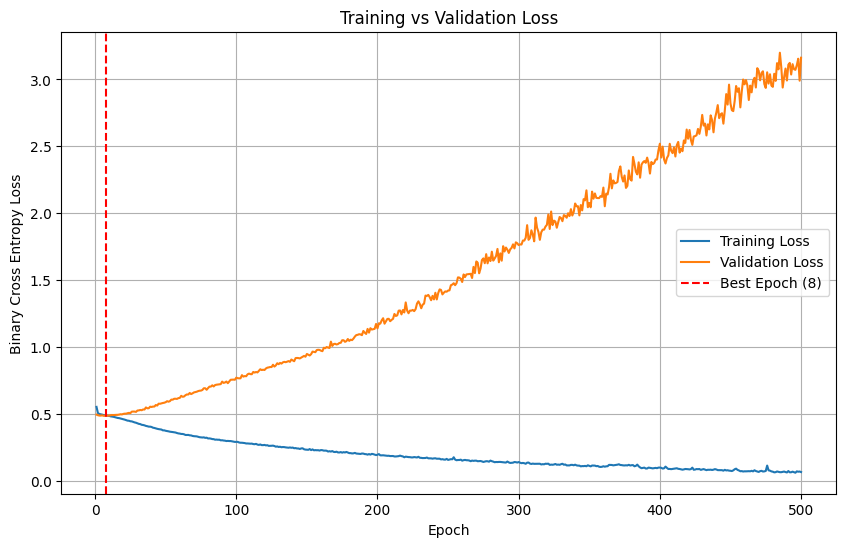

In [23]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(10,6))

plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")

best_epoch = val_losses.index(min(val_losses)) + 1

plt.axvline(best_epoch, linestyle="--", color="red",
            label=f"Best Epoch ({best_epoch})")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")

plt.legend()
plt.grid(True)

plt.show()

Looking at the loss curves, we can see that the validation loss is increases almost immediately  and continues until the final epoch. The training loss continues to decrease very slowly throughout. Our validation loss appears to be increasing, despite the decreasing training loss; this phenomenon is known as overfitting. Essentially, this means our neural network is no longer learning how and which indicators logically predict loan defaults, and starts fitting the noise by trying to "memorize" the results; kind of like trying to cheat on a test. Our model had already reached its minimum validation loss by epoch 8, so all the training afterwards just continues to contribute to heavier and heavier overfitting.

Test Accuracy: 0.7627
Test Recall: 0.1639
Test AUC: 0.6845


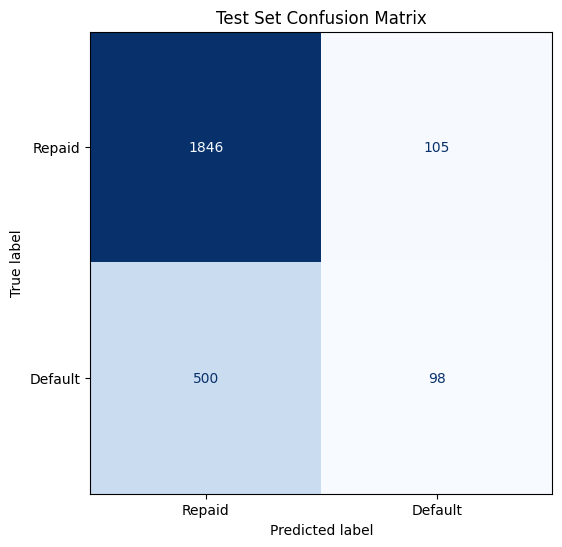

In [24]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
results = []
# Load best model
model.load_state_dict(best_model_weights)
model.eval()
with torch.no_grad():

    test_outputs = model(X_test_tensor)

    test_predictions = (test_outputs >= 0.5).float()
# Convert to numpy
y_test_np = y_test_tensor.numpy().ravel()
preds_np = test_predictions.numpy().ravel()
probs_np = test_outputs.numpy().ravel()
# Metrics
accuracy = accuracy_score(y_test_np, preds_np)
recall = recall_score(y_test_np, preds_np)
auc = roc_auc_score(y_test_np, probs_np)
print("Test Accuracy:", round(accuracy,4))
print("Test Recall:", round(recall,4))
print("Test AUC:", round(auc,4))

results.append({
    "Model": 'Baseline',
    "Accuracy": round(accuracy,4),
    "Recall": round(recall,4),
    "AUC": round(auc,4)
})

# 4. Generate and Plot the Confusion Matrix
cm = confusion_matrix(y_test_np, preds_np)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Repaid", "Default"]
)
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", ax=plt.gca(), colorbar=False)
plt.title("Test Set Confusion Matrix")
plt.show()

When applying the model to our test data, we get that accuracy is at 76%, and a recall of 16%, where our network predicted 98 out of 598 true defaults. Despite the rather poor of our neural network, the AUC is 0.68 (>0.5), which suggests that our model is actually better than random guessing. This suggests that our network is learning and likely can improve with better feature selection, threshold tuning, and changing the dimensions of the network.

## 3. Experimentation

From our baseline model, we can continue to experiment with configurations such as architecture, regularization, learning rate, batch size, number of epochs, and early stopping. Similar to before, we track the best model weights during training.

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def train_and_evaluate(model, criterion, optimizer, model_name):

    epochs = 500
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_weights = None

    for epoch in range(epochs):

        # ---- Training ----
        model.train()
        epoch_train_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            if isinstance(criterion, nn.BCEWithLogitsLoss):
                loss = criterion(outputs, y_batch)
            else:
                loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---- Validation ----
        model.eval()
        with torch.no_grad():

            val_outputs = model(X_val_tensor)

            val_loss = criterion(val_outputs, y_val_tensor).item()

            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_weights = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 50 == 0:
            print(
                f"{model_name} Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {avg_train_loss:.4f} "
                f"Val Loss: {val_loss:.4f}"
            )

    # ---- Plot Loss Curves ----
    best_epoch = val_losses.index(min(val_losses)) + 1

    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title(f"{model_name} Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.axvline(best_epoch, linestyle="--", color="red", label=f"Best Epoch ({best_epoch})")
    plt.legend()
    plt.show()

    


    # ---- Load Best Model ----
    model.load_state_dict(best_model_weights)
    model.eval()
    

    with torch.no_grad():

        outputs = model(X_test_tensor)

        if isinstance(criterion, nn.BCEWithLogitsLoss):
            probs = torch.sigmoid(outputs)
        else:
            probs = outputs

        preds = (probs >= 0.5).float()

    y_test_np = y_test_tensor.numpy().ravel()
    preds_np = preds.numpy().ravel()
    probs_np = probs.numpy().ravel()

    accuracy = accuracy_score(y_test_np, preds_np)
    recall = recall_score(y_test_np, preds_np)
    auc = roc_auc_score(y_test_np, probs_np)

    print(f"\n{model_name} Results")
    print("Accuracy:", round(accuracy,4))
    print("Recall:", round(recall,4))
    print("AUC:", round(auc,4))
    
    results.append({
    "Model": model_name,
    "Accuracy": round(accuracy,4),
    "Recall": round(recall,4),
    "AUC": round(auc,4)
})

    # Confusion Matrix
    cm = confusion_matrix(y_test_np, preds_np)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Repaid","Default"])

    disp.plot(cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

### 3.1 Weighted Neural Network

The first configuration we chose was a weighted neural network. The weighted neural network weighs by class, and will help adjust for the class imbalance in our dataset. This should help us increase our recall. To do this, we will use BCEWithLogitsLoss. This will make the importance of identifying defaults more important than identifying non-defaults.

In [26]:
import torch.nn as nn

class WeightedNet(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.output(x)   # NO sigmoid here

        return x

Class Weighted NN Epoch [50/500] Train Loss: 0.7081 Val Loss: 1.1769
Class Weighted NN Epoch [100/500] Train Loss: 0.5225 Val Loss: 1.6996
Class Weighted NN Epoch [150/500] Train Loss: 0.4082 Val Loss: 2.1632
Class Weighted NN Epoch [200/500] Train Loss: 0.3190 Val Loss: 2.7523
Class Weighted NN Epoch [250/500] Train Loss: 0.2614 Val Loss: 3.2287
Class Weighted NN Epoch [300/500] Train Loss: 0.2115 Val Loss: 3.8260
Class Weighted NN Epoch [350/500] Train Loss: 0.1770 Val Loss: 4.2719
Class Weighted NN Epoch [400/500] Train Loss: 0.1451 Val Loss: 4.8573
Class Weighted NN Epoch [450/500] Train Loss: 0.1124 Val Loss: 5.6425
Class Weighted NN Epoch [500/500] Train Loss: 0.0954 Val Loss: 5.9501


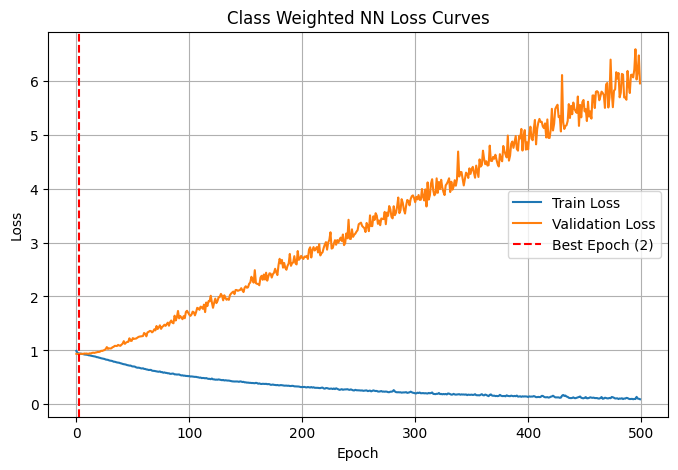


Class Weighted NN Results
Accuracy: 0.645
Recall: 0.6204
AUC: 0.691


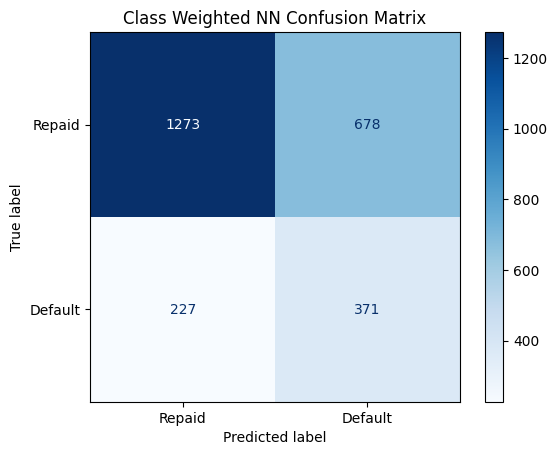

In [27]:
model1 = WeightedNet(input_dim)

pos_weight = torch.tensor([
    (len(y_train_tensor) - y_train_tensor.sum()) / y_train_tensor.sum()
])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model1.parameters(), lr=0.001)

train_and_evaluate(model1, criterion, optimizer, "Class Weighted NN")

From the results, we see that accuracy decreased to 64%, but recall shot up to 62% and the network identified 371 correct cases of default out of 598. Class weighting significantly improved recall because the model became more sensitive to default cases. While accuracy typically decreased slightly due to more false positives, the model was better able to identify borrowers who were likely to default. Therefore, the weighted neural network was able to achieve a better performance with its significantly higher recall and higher AUC.

### 3.2 Dropout

The second experimental model I wanted to test was dropout. Dropout works by randomly disabling a fraction of neurons during training. This prevents the model from relying too heavily on specific neurons and forces it to learn more robust feature representations. This would help with overfitting, which we identified as a significant issue with our baseline model. We set dropout_rate as 0.3 or 30%, which means that every iteration 30% of neurons are deactivated. 

In [28]:
import torch.nn as nn

class DropoutNet(nn.Module):

    def __init__(self, input_size, dropout_rate=0.3):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.sigmoid(self.output(x))

        return x

Dropout NN Epoch [50/500] Train Loss: 0.4764 Val Loss: 0.4918
Dropout NN Epoch [100/500] Train Loss: 0.4535 Val Loss: 0.5016
Dropout NN Epoch [150/500] Train Loss: 0.4425 Val Loss: 0.5100
Dropout NN Epoch [200/500] Train Loss: 0.4315 Val Loss: 0.5211
Dropout NN Epoch [250/500] Train Loss: 0.4156 Val Loss: 0.5225
Dropout NN Epoch [300/500] Train Loss: 0.4187 Val Loss: 0.5241
Dropout NN Epoch [350/500] Train Loss: 0.4132 Val Loss: 0.5290
Dropout NN Epoch [400/500] Train Loss: 0.4076 Val Loss: 0.5330
Dropout NN Epoch [450/500] Train Loss: 0.4173 Val Loss: 0.5318
Dropout NN Epoch [500/500] Train Loss: 0.4040 Val Loss: 0.5376


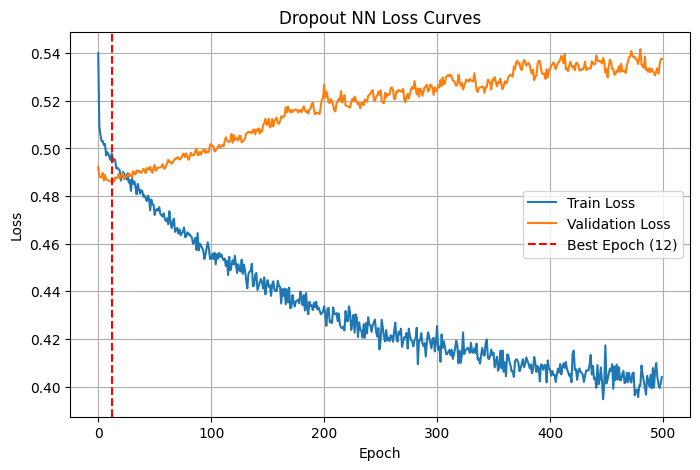


Dropout NN Results
Accuracy: 0.7689
Recall: 0.1338
AUC: 0.6895


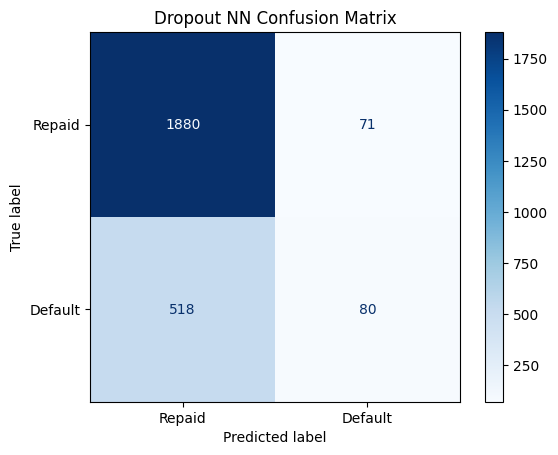

In [29]:
model = DropoutNet(input_dim, dropout_rate=0.3)

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

train_and_evaluate(model, criterion, optimizer, "Dropout NN")

The dropout neural network produced a lot lower validation loss according to the plot and helped reduce overfitting. The curve was a lot flatter and reached a plateau near 400-500 epochs, showing how the severe overfitting was limited. However, dropout alone does not directly address class imbalance, so the recall fell compared to the original model. The dropout neural network only ended up identifying 80 true defaults. Although the loss curves are more controlled, this experimental network did not seem to improve the model based on metrics alone.

### 3.3 Small Net

The third and final experiment I ran was to use a smaller neural network by adjusting the architecture. The baseline neural network uses two hidden layers with 64 neurons each. While this architecture is relatively small compared to deep learning models used in image or language tasks, it might still be too complex for our dataset, which primarily consists of tabular data. If the neural network has too many parameters and is too complex, it might overfit more easily by memorizing patterns rather than learning actual generalizable relationships.

The smaller neural network uses two layers of 32 and 16 neurons, which decreases the trainable parameters significantly.


SmallNet NN Epoch [50/500] Train Loss: 0.4508 Val Loss: 0.5082
SmallNet NN Epoch [100/500] Train Loss: 0.4192 Val Loss: 0.5484
SmallNet NN Epoch [150/500] Train Loss: 0.3995 Val Loss: 0.5828
SmallNet NN Epoch [200/500] Train Loss: 0.3855 Val Loss: 0.6248
SmallNet NN Epoch [250/500] Train Loss: 0.3777 Val Loss: 0.6558
SmallNet NN Epoch [300/500] Train Loss: 0.3720 Val Loss: 0.6824
SmallNet NN Epoch [350/500] Train Loss: 0.3645 Val Loss: 0.7047
SmallNet NN Epoch [400/500] Train Loss: 0.3564 Val Loss: 0.7272
SmallNet NN Epoch [450/500] Train Loss: 0.3503 Val Loss: 0.7631
SmallNet NN Epoch [500/500] Train Loss: 0.3475 Val Loss: 0.7856


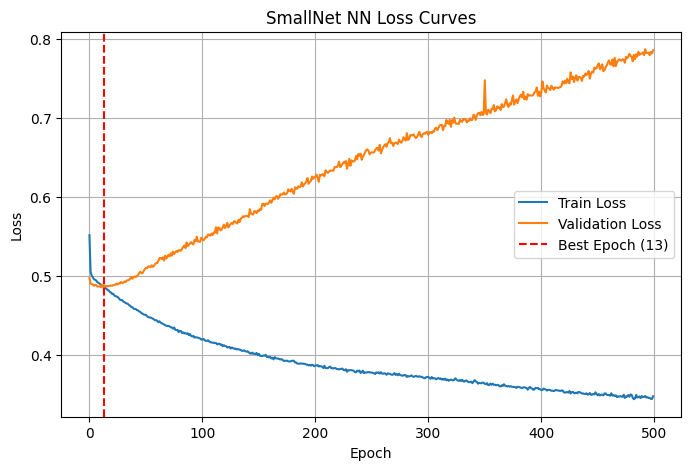


SmallNet NN Results
Accuracy: 0.7642
Recall: 0.1405
AUC: 0.6851


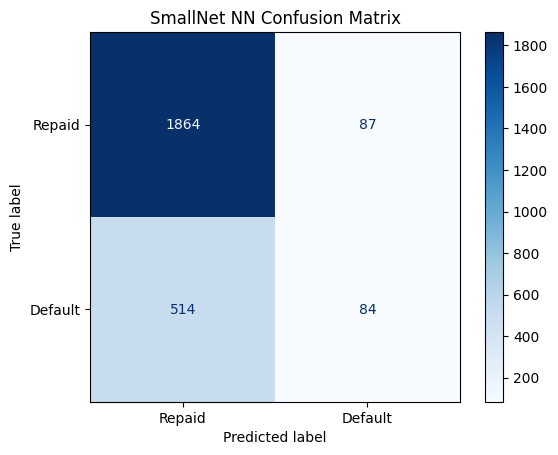

In [30]:
class SmallNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.output(x))
        return x
torch.manual_seed(42)

model = SmallNet(input_dim)

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)
train_and_evaluate(model, criterion, optimizer, "SmallNet NN")


From the plot, we get that the model is indeed able to train for longer, as the best epoch is at epoch 13. This suggests that it takes longer for the model to start overfitting. From the metrics, accuracy and AUC remain similar to the baseline network. However, recall is slightly lower 

### 3.4 Comparison and Results

In [31]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Recall,AUC
0,Baseline,0.7627,0.1639,0.6845
1,Class Weighted NN,0.6450,0.6204,0.6910
2,Dropout NN,0.7689,0.1338,0.6895
3,SmallNet NN,0.7642,0.1405,0.6851


From this table, we get the results of the baseline model and all three experimental models side-by-side. The baseline, dropout, and smallnet neural networks all performed similarly based on accuracy and AUC, but when it came to recall, the class weighted neural network performed significantly better.  

In terms of which model performed the best, we would recommend the class weighted neural network as the best-performing model. First, it was able to achieve the best recall by far, and correctly identified over 60% of the true defaults. When it comes to credit companies predicting defaults, recall is the most important indicator because missing a case has high consequences. Furthermore, the accuracy metric can be extremely misleading due to the imbalanced nature of our dataset. A model which barely predicts any defaults would still be able to achieve a high accuracy. Finally, the class weighted network also had the highest AUC of 0.69, showing that despite lower accuracy, it still had higher overall performance.

Overall, for the firm trying to identify as many defaults as possible, the class weighted neural network outperforms the baseline and other experimental networks, and should be implemented first.

## 4. Comparison to Lab Report 5

In Lab Report 5, we ran a logistic regression, random forest, and XGBoost model on the same data. Here, we refit those models and evaluate using the metrics of accuracy, recall, and AUC.
  
We use the same hyperparameters we got in Lab Report 5. Those hyperparameters were achieved through a 5-fold crossvalidation.

### 4.1 Fitting Models

In [32]:
import numpy as np

X_train_np = X_train_tensor.numpy()
X_test_np = X_test_tensor.numpy()

y_train_np = y_train_tensor.numpy().ravel()
y_test_np = y_test_tensor.numpy().ravel()

X_train_np = X_train_np.astype("float32")
X_test_np = X_test_np.astype("float32")

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=23,
    class_weight='balanced'
)

log_reg.fit(X_train_np, y_train_np)

log_probs = log_reg.predict_proba(X_test_np)[:, 1]
log_preds = (log_probs >= 0.5).astype(int)

log_acc = accuracy_score(y_test_np, log_preds)
log_rec = recall_score(y_test_np, log_preds)
log_auc = roc_auc_score(y_test_np, log_probs)

print("Logistic Regression")
print("Accuracy:", round(log_acc, 4))
print("Recall:", round(log_rec, 4))
print("AUC:", round(log_auc, 4))

Logistic Regression
Accuracy: 0.6363
Recall: 0.6472
AUC: 0.6944


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    random_state=23,
    max_features='sqrt',
    n_jobs = 1
)

rf_model.fit(X_train_np, y_train_np)

rf_probs = rf_model.predict_proba(X_test_np)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

rf_acc = accuracy_score(y_test_np, rf_preds)
rf_rec = recall_score(y_test_np, rf_preds)
rf_auc = roc_auc_score(y_test_np, rf_probs)

print("Random Forest")
print("Accuracy:", round(rf_acc, 4))
print("Recall:", round(rf_rec, 4))
print("AUC:", round(rf_auc, 4))

Random Forest
Accuracy: 0.7666
Recall: 0.0117
AUC: 0.6977


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=23,
    eval_metric='logloss',
    n_jobs = 1
)

xgb_model.fit(X_train_np, y_train_np)

xgb_probs = xgb_model.predict_proba(X_test_np)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

xgb_acc = accuracy_score(y_test_np, xgb_preds)
xgb_rec = recall_score(y_test_np, xgb_preds)
xgb_auc = roc_auc_score(y_test_np, xgb_probs)

print("XGBoost")
print("Accuracy:", round(xgb_acc, 4))
print("Recall:", round(xgb_rec, 4))
print("AUC:", round(xgb_auc, 4))

XGBoost
Accuracy: 0.7497
Recall: 0.2157
AUC: 0.6523


In [39]:
# Assume best_nn_model is already trained and best weights already loaded
model1.eval()

with torch.no_grad():
    nn_outputs = model1(X_test_tensor)

    # If best model used BCEWithLogitsLoss
    nn_probs = torch.sigmoid(nn_outputs).numpy().ravel()

    # If best model used BCELoss with sigmoid already in the network, use:
    # nn_probs = nn_outputs.numpy().ravel()

nn_preds = (nn_probs >= 0.5).astype(int)

nn_acc = accuracy_score(y_test_np, nn_preds)
nn_rec = recall_score(y_test_np, nn_preds)
nn_auc = roc_auc_score(y_test_np, nn_probs)

print("Class Weighted Neural Network")
print("Accuracy:", round(nn_acc, 4))
print("Recall:", round(nn_rec, 4))
print("AUC:", round(nn_auc, 4))

Class Weighted Neural Network
Accuracy: 0.645
Recall: 0.6204
AUC: 0.691


### 4.2 Metrics

In [42]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Class Weighted Best Neural Network"
    ],
    "Accuracy": [
        round(log_acc, 4),
        round(rf_acc, 4),
        round(xgb_acc, 4),
        round(nn_acc, 4)
    ],
    "Recall": [
        round(log_rec, 4),
        round(rf_rec, 4),
        round(xgb_rec, 4),
        round(nn_rec, 4)
    ],
    "AUC": [
        round(log_auc, 4),
        round(rf_auc, 4),
        round(xgb_auc, 4),
        round(nn_auc, 4)
    ]
})

comparison_df.sort_values("Recall", ascending=False)

,Model,Accuracy,Recall,AUC
0,Logistic Regression,0.6363,0.6472,0.6944
3,Class Weighted Best Neural Network,0.6450,0.6204,0.6910
2,XGBoost,0.7497,0.2157,0.6523
1,Random Forest,0.7666,0.0117,0.6977


The table above shows the model metrics across all four models based on accuracy, recall, and AUC.

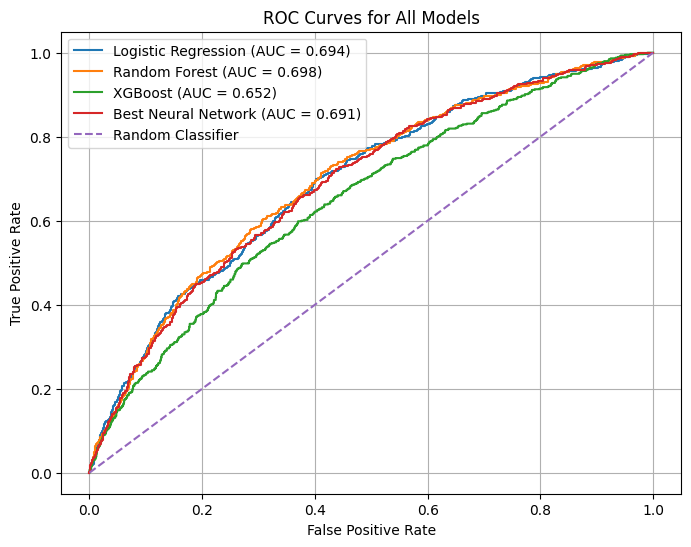

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

log_fpr, log_tpr, _ = roc_curve(y_test_np, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test_np, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test_np, xgb_probs)
nn_fpr, nn_tpr, _ = roc_curve(y_test_np, nn_probs)

plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")
plt.plot(nn_fpr, nn_tpr, label=f"Best Neural Network (AUC = {nn_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(True)
plt.show()

The ROC curve plots the True Positive Rate, or recall, against the False Positive Rate at every possible classification threshold. A perfect classifier would go along the top left corner, while a completely random classifier would go up at a 45 degree angle as visualized by the purple dashed line. We want the area under the curve or AUC to be as large as possible.

From our metrics, the Random Forest has the highest AUC of 0.70. This means it is the best at ranking borrowers more likely to default above those who are not. Our best neural network performs solid as well, with an AUC of 0.69. This shows that the neural network still has a solid performance compared to the other models. The worst performing model was the XGBoost, represented by the green line, and it is clearly the closest to a random classifier.

### 4.3 Evaluation: Neural Networks V.S. SKLearn

In [43]:
comparison_df

,Model,Accuracy,Recall,AUC
0,Logistic Regression,0.6363,0.6472,0.6944
1,Random Forest,0.7666,0.0117,0.6977
2,XGBoost,0.7497,0.2157,0.6523
3,Class Weighted Best Neural Network,0.6450,0.6204,0.6910


Accuracy alone can be misleading in this dataset because loan defaults are relatively rare compared to fully repaid loans. As a result, models that primarily predict the majority class can achieve high accuracy while failing to identify default cases. For this reason, recall and AUC provide more meaningful measures of performance. 

From the ROC plot, we know that the Random Forest achieved the highest AUC of 0.7. However, its recall was extremely low at 0.01, meaning that it identified almost none of the actual default cases. This indicates that the model primarily predicts loans as non-default, which is common in highly imbalanced datasets. Logistic Regression achieved the highest recall of 0.65, indicating that it was most effective at identifying default cases. However, this came with lower overall accuracy, as the model predicted defaults more frequently. XGBoost achieved a relatively high accuracy (0.7497) but a much lower recall (0.2157), indicating that it still struggled to detect default cases despite its strong performance on many tabular datasets.
  
The class-weighted neural network achieved a recall of 0.6204, which is comparable to Logistic Regression, while maintaining slightly higher accuracy. The use of class weighting helped the neural network better detect minority-class defaults by penalizing misclassification of default cases more heavily during training. Overall, from the high recall and the solid AUC, we believe the class weighted neural network remains the best model in this group and would recommend its use. 

However, the neural network does not clearly outperform the traditional sklearn models on this dataset by a lot. The class-weighted neural network achieved strong recall and competitive AUC, but it did not significantly exceed the performance of Logistic Regression or Random Forest, and was also lacking in accuracy.
  
This result is consistent with what we learned in class that neural networks often do not outperform simpler models on relatively small tabular datasets. Random Forest and gradient boosting algorithms often perform very well on structured financial data because they naturally capture nonlinear relationships and interactions between variables.
  
Neural networks are superior in settings where there are large datasets, complex nonlinear relationships, and data types (text, images) that simpler models cannot handle natively.The Lending Club dataset is a relatively small structured dataset with tabular financial features. In such settings, simpler models like Logistic Regression and tree-based methods are still able remain competitive.

Moving forward, if the Lending Club dataset got sufficiently larger, or the data increased in nuance such as text, image, or more, the advantages of a neural network would shine through much clearer, and it would become the obvious choice for use. For now and this specific dataset, either works perfectly well.